# Notebook 1: Behavioral Screening (Experiment 1)

Reproduces **Table S1** (calibration metrics for all 6 models) and
**Figure 2** (confidence distributions and calibration gaps).

**Data sources:** V4 model-relative summaries for Tier 1, original summaries for Tier 2.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# Paths relative to repo root (run from analysis/ or adjust)
BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")

## 1. Load model response summaries

In [2]:
tier1_files = {
    "Mistral 7B": "data/responses/tier1/mistral7b_v4_summary.json",
    "Llama 3.1 8B": "data/responses/tier1/llama8b_v4_summary.json",
    "Gemma 2 9B": "data/responses/tier1/gemma9b_v4_summary.json",
}
tier2_files = {
    "GPT-4o": "data/responses/tier2/gpt4o_summary.json",
    "Gemini 2.0 Flash": "data/responses/tier2/gemini_summary.json",
    "Sonnet 3.5": "data/responses/tier2/sonnet_summary.json",
}

summaries = {}
for name, path in {**tier1_files, **tier2_files}.items():
    with open(os.path.join(BASE, path)) as f:
        summaries[name] = json.load(f)
    print(f"Loaded {name}: {summaries[name]['total_questions']} questions, "
          f"labels K={summaries[name]['model_label_counts']['K']}, "
          f"D={summaries[name]['model_label_counts']['D']}, "
          f"C={summaries[name]['model_label_counts']['C']}")

Loaded Mistral 7B: 338 questions, labels K=212, D=77, C=49
Loaded Llama 3.1 8B: 338 questions, labels K=216, D=95, C=27
Loaded Gemma 2 9B: 338 questions, labels K=219, D=42, C=77
Loaded GPT-4o: 338 questions, labels K=290, D=24, C=24
Loaded Gemini 2.0 Flash: 338 questions, labels K=269, D=23, C=46
Loaded Sonnet 3.5: 338 questions, labels K=299, D=3, C=36


## 2. Table S1: Calibration metrics

For each model, compute:
- K/D/C label counts (model-relative for Tier 1, original for Tier 2)
- Mean confidence per label
- Accuracy per label
- K-D miscalibration gap (difference between D-confidence and D-accuracy)

In [3]:
# Also load canonical experiment 1 for cross-checked values
with open(os.path.join(BASE, "results/canonical/experiment_1.json")) as f:
    canonical_exp1 = json.load(f)

print(f"{'Model':<20} {'Tier':>4} {'K':>4} {'D':>4} {'C':>4} "
      f"{'K_conf':>7} {'D_conf':>7} {'K_acc':>6} {'D_acc':>6} "
      f"{'D_overconf':>10}")
print("-" * 95)

for name, s in summaries.items():
    cal = s["calibration"]
    lc = s["model_label_counts"]
    tier = "T1" if name in tier1_files else "T2"

    k_conf = cal["K"]["mean_confidence"]
    d_conf = cal["D"]["mean_confidence"]
    k_acc = cal["K"]["accuracy_in_confidence_condition"]
    d_acc = cal["D"]["accuracy_in_confidence_condition"]
    d_overconf = d_conf - d_acc

    print(f"{name:<20} {tier:>4} {lc['K']:>4} {lc['D']:>4} {lc['C']:>4} "
          f"{k_conf:>7.4f} {d_conf:>7.4f} {k_acc:>6.4f} {d_acc:>6.4f} "
          f"{d_overconf:>10.4f}")

    # Cross-check against canonical
    can_model = canonical_exp1["models"].get(name, {})
    if can_model:
        can_lc = can_model["label_counts"]
        assert can_lc["K"] == lc["K"], f"{name} K mismatch: {can_lc['K']} vs {lc['K']}"
        assert can_lc["D"] == lc["D"], f"{name} D mismatch: {can_lc['D']} vs {lc['D']}"
        print(f"  [cross-check OK: canonical K={can_lc['K']}, D={can_lc['D']}, C={can_lc['C']}]")

Model                Tier    K    D    C  K_conf  D_conf  K_acc  D_acc D_overconf
-----------------------------------------------------------------------------------------------
Mistral 7B             T1  212   77   49  0.9954  0.9894 0.9151 0.5065     0.4829
  [cross-check OK: canonical K=212, D=77, C=49]
Llama 3.1 8B           T1  216   95   27  0.9099  0.7123 0.7692 0.3014     0.4109
  [cross-check OK: canonical K=216, D=95, C=27]
Gemma 2 9B             T1  219   42   77  0.9988  0.9702 0.9909 0.5476     0.4226
  [cross-check OK: canonical K=219, D=42, C=77]
GPT-4o                 T2  290   24   24  0.9467  0.5565 1.0000 0.9130    -0.3565
  [cross-check OK: canonical K=290, D=24, C=24]
Gemini 2.0 Flash       T2  269   23   46  0.9984  0.9773 0.9888 0.5455     0.4318
  [cross-check OK: canonical K=269, D=23, C=46]
Sonnet 3.5             T2  299    3   36  0.9286  0.8833 1.0000 1.0000    -0.1167
  [cross-check OK: canonical K=299, D=3, C=36]


## 3. Figure 2: Confidence distributions and calibration gaps

Panel A: Per-model confidence distributions for K vs D items (box plots).
Panel B: D-overconfidence (mean D confidence minus mean D accuracy) across models.

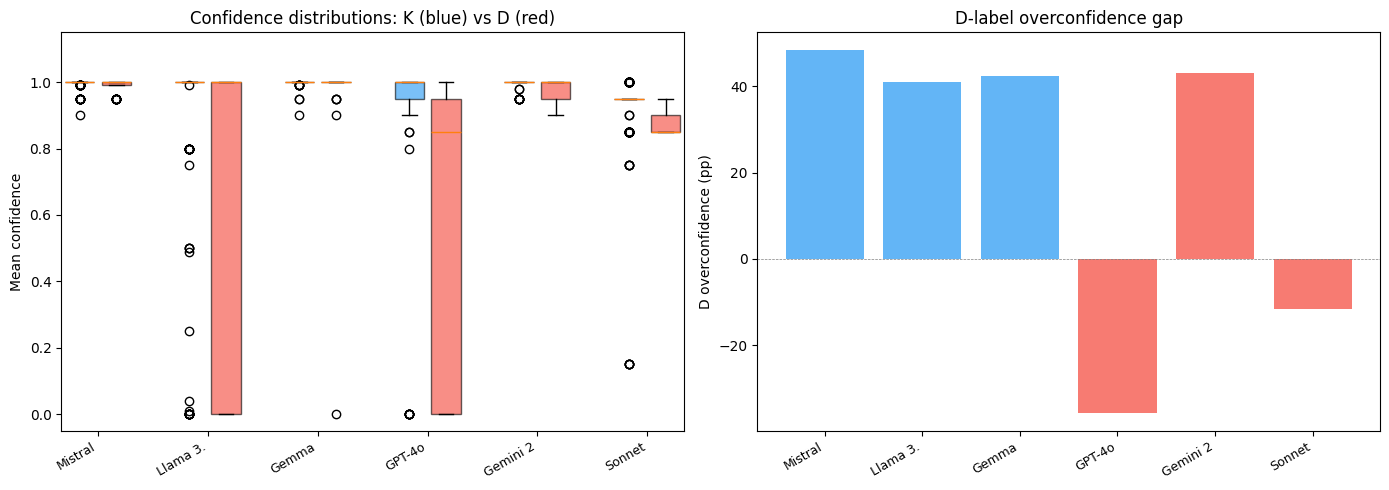

Saved fig2_behavioral_screening.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Confidence distributions ---
ax = axes[0]
models_ordered = ["Mistral 7B", "Llama 3.1 8B", "Gemma 2 9B",
                  "GPT-4o", "Gemini 2.0 Flash", "Sonnet 3.5"]
positions = []
labels_x = []
colors_k = "#2196F3"
colors_d = "#F44336"

for i, name in enumerate(models_ordered):
    can = canonical_exp1["models"][name]
    k_confs = can["per_question_confidence"]["K"]
    d_confs = can["per_question_confidence"]["D"]

    bp_k = ax.boxplot([k_confs], positions=[i * 3], widths=0.8,
                      patch_artist=True, showfliers=True)
    bp_d = ax.boxplot([d_confs], positions=[i * 3 + 1], widths=0.8,
                      patch_artist=True, showfliers=True)

    bp_k["boxes"][0].set_facecolor(colors_k)
    bp_k["boxes"][0].set_alpha(0.6)
    bp_d["boxes"][0].set_facecolor(colors_d)
    bp_d["boxes"][0].set_alpha(0.6)

    positions.append(i * 3 + 0.5)
    short = name.split()[0] if len(name) < 12 else name[:8]
    labels_x.append(short)

ax.set_xticks(positions)
ax.set_xticklabels(labels_x, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean confidence")
ax.set_title("Confidence distributions: K (blue) vs D (red)")
ax.set_ylim(-0.05, 1.15)

# --- Panel B: D-overconfidence ---
ax = axes[1]
overconf = []
for name in models_ordered:
    cal = summaries[name]["calibration"]
    d_over = cal["D"]["mean_confidence"] - cal["D"]["accuracy_in_confidence_condition"]
    overconf.append(d_over * 100)  # percentage points

bar_colors = [colors_k] * 3 + [colors_d] * 3
ax.bar(range(len(models_ordered)), overconf, color=bar_colors, alpha=0.7)
ax.set_xticks(range(len(models_ordered)))
ax.set_xticklabels([m.split()[0] if len(m) < 12 else m[:8]
                     for m in models_ordered], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("D overconfidence (pp)")
ax.set_title("D-label overconfidence gap")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("fig2_behavioral_screening.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_behavioral_screening.png")

## 4. Cross-tabulation: construction types vs model labels

Shows how the 6 construction categories (K, D1, D2, D3, C1, C2) map to
model-relative labels for each Tier 1 model.

In [5]:
for name in ["Mistral 7B", "Llama 3.1 8B", "Gemma 2 9B"]:
    s = summaries[name]
    print(f"\n=== {name} ===")
    xt = s["cross_tabulation"]
    print(f"  {'Type':<6} {'->K':>5} {'->D':>5} {'->C':>5}")
    for ctype in ["K", "D1", "D2", "D3", "C1", "C2"]:
        row = xt.get(ctype, {})
        print(f"  {ctype:<6} {row.get('K', 0):>5} {row.get('D', 0):>5} {row.get('C', 0):>5}")


=== Mistral 7B ===
  Type     ->K   ->D   ->C
  K        192    18     0
  D1         2     3     0
  D2        18    56     9
  D3         0     0     1
  C1         0     0    23
  C2         0     0    16

=== Llama 3.1 8B ===
  Type     ->K   ->D   ->C
  K        179    27     4
  D1         3     2     0
  D2        31    47     5
  D3         1     0     0
  C1         1    18     4
  C2         1     1    14

=== Gemma 2 9B ===
  Type     ->K   ->D   ->C
  K        182    16    12
  D1         3     1     1
  D2        33    24    26
  D3         1     0     0
  C1         0     1    22
  C2         0     0    16


## 5. Data quality check

Verify label counts sum to 338 for each model, and that K + D + C = total.

In [6]:
for name, s in summaries.items():
    lc = s["model_label_counts"]
    total = lc["K"] + lc["D"] + lc["C"]
    assert total == 338, f"{name}: K+D+C = {total}, expected 338"
    assert s["total_questions"] == 338, f"{name}: total_questions = {s['total_questions']}"
    print(f"{name}: K={lc['K']}, D={lc['D']}, C={lc['C']}, sum={total} [OK]")
print("\nAll models have 338 questions with valid K+D+C partition.")

Mistral 7B: K=212, D=77, C=49, sum=338 [OK]
Llama 3.1 8B: K=216, D=95, C=27, sum=338 [OK]
Gemma 2 9B: K=219, D=42, C=77, sum=338 [OK]
GPT-4o: K=290, D=24, C=24, sum=338 [OK]
Gemini 2.0 Flash: K=269, D=23, C=46, sum=338 [OK]
Sonnet 3.5: K=299, D=3, C=36, sum=338 [OK]

All models have 338 questions with valid K+D+C partition.
